# Makemore
makemore is a NN that generates new names from a set of names it learns from. This is a taster for how LLMs work.
makemore shows how words are generated, it learns names as sequences of characters that helps the models to predict what letter comes after another.

### This notebook will be on building a MLP along the lines of Bengio et al.'s work https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf

our previous notebook built a character level language model, but Bengio's work (which trained on 17,000 words) built a word level language model. Their work allows words of similar meanings to occupy a similar space.

The model approach is identical, they identify what word comes after another word, and they optimize the model by maximizing the log-likelihood.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# let's read names.txt
words = open('makemore_files/names.txt', 'r').read().splitlines()

In [3]:
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
# names.txt statistics
print(f'we have {len(words)} names in the list')
print(f'the shortest name has {min(len(w) for w in words)} characters')
print(f'the longest name has {max(len(w) for w in words)} characters')

we have 32033 names in the list
the shortest name has 2 characters
the longest name has 15 characters


In [5]:
# build some useful lists and dictionaries

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [6]:
# build the dataset

block_size = 3 # context length: how many previous characters do we use to predict the next one
X, Y = [], []
for w in words[:5]:
    print(w)
    context = [0] * block_size # context stores the integer equivalent for the characters. start with a list of 0s
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:]+[ix] # crop out first entry and append new entry

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [7]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [8]:
# let's build our embedding
# First, let's build the lookup table C
# in this case, we only have 26+1= 27 possible characters
# Let's arbitrarily start by embedding each character to a 2D space

C = torch.randn((27,2))

In [9]:
# pytorch has a really great way of building embedding. We can input our training data X into a lookup table to generate an embedding for X

emb = C[X]
print(emb.shape)
print('note how the emb dimension is 32x3x2, 32x3 is from X and now each input has 2 values associated with it because we chose a 2D embedding')

torch.Size([32, 3, 2])
note how the emb dimension is 32x3x2, 32x3 is from X and now each input has 2 values associated with it because we chose a 2D embedding


In [10]:
# recall we can also use one hot encoding to call specific character encodings. simple dot product where only one element is non-zero
F.one_hot(torch.tensor([5,6]), num_classes=27).float() @ C

tensor([[-0.9806, -1.0967],
        [-0.1912, -0.3067]])

In [11]:
# now let's contruct the hidden layer in our NN
# in this example, we have 3 2D embeddings per entry, so the number of inputs we have is 3*2=6.
# let's start with 100 neurons

W1 = torch.randn((6,100))
b1 = torch.randn(100)

print('note that adding W1 and b1 is possible though the dimensions seem to not match up.')
print('this is because pytorch does broadcasting automatically, which first aligns the dimensions to the right (columns) then copies the smaller tensor along the missing dimension.')
print('doing b1 = torch.randn((1,100)) would also work, but is not necessary.')

note that adding W1 and b1 is possible though the dimensions seem to not match up.
this is because pytorch does broadcasting automatically, which first aligns the dimensions to the right (columns) then copies the smaller tensor along the missing dimension.
doing b1 = torch.randn((1,100)) would also work, but is not necessary.


In [12]:
# we want to do something along the lines of emb*weights + bias
# note emb has dimensions 32x3x2 while weights have 6x100
# we cannot do a matrix multiplication emb@W because the dimensions don't match up
# this is because the last 3x2 in emb is a stacked up version of weight's 6
    # i.e. [[a,b],[c,d],[e,f]] * [w_a, w_b, w_c, w_d, w_e, w_f]
# we want to transform emb's [[a,b],[c,d],[e,f]] --> [a,b,c,d,e,f] so that we can do a matrix multiplication with W1
# pytorch has a very nice function that does this, called .view. We can use .view to reshape the tensor into a new shape. In this case, we want to reshape emb from 32x3x2 to 32x6

print('original emb shape:', emb.shape)
print('transformed with .view():', emb.view(32,6).shape)
print('')

# now we can do emb @ W1

pre_tanh = emb.view(-1,6) @ W1 # below are equivalent ways to do the same thing for this example
# pre_tanh = emb.view(32,6) @ W1
# pre_tanh = emb.view(emb.shape[0],6) @ W1
print('note we use -1 in the first dimension instead of 32.')
print('-1 tells pytorch to automatically calculate the correct dimensions, and makes the model flexible instead of having the user specific the dimensions every time')

h = torch.tanh(pre_tanh + b1) # recall broadcasting allows us to add our bias b1 though b1 is a 1D vector

original emb shape: torch.Size([32, 3, 2])
transformed with .view(): torch.Size([32, 6])

note we use -1 in the first dimension instead of 32.
-1 tells pytorch to automatically calculate the correct dimensions, and makes the model flexible instead of having the user specific the dimensions every time


In [13]:
# finally, let's create the final (output) layer of our NN.
# recall we have 27 characters, so we want to output a 27 element vector for each input. (instead of the 100 neurons in W1)

W2 = torch.randn((100,27)) # we take in 100 inputs from W1 and release 27 outputs
b2 = torch.randn(27)

In [14]:
logits = h @ W2 + b2 # we don't have to do the whole .view() thing here because we are not taking in embeddings
# why do we call it logits? something for me to look up later. I could really call it anything but labelling it properly is good for looking back at the code if there are any bugs/issues

counts = logits.exp() # apply exp() as part of softmax (converting logits to probabilities). This is much like boltzmann and fermi weighting
prob = counts / counts.sum(1, keepdims=True) # apply softmax to get probabilities. Recall 1 tells torch to sum along the first dimension (rows)

In [15]:
print('final shape of probabilities:', prob.shape)
print('this corresponds to 32 separate outputs of one-hot encoded vectors (27 elements), aligned with the 32 inputs we have')
print('check probabilities are normalized, all 1s is good:\n', prob.sum(1))

final shape of probabilities: torch.Size([32, 27])
this corresponds to 32 separate outputs of one-hot encoded vectors (27 elements), aligned with the 32 inputs we have
check probabilities are normalized, all 1s is good:
 tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [16]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [17]:
print('Y, ground truthoutput')
print(Y)
print([itos[i] for i in [y.item() for y in Y]])

Y, ground truthoutput
tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])
['e', 'm', 'm', 'a', '.', 'o', 'l', 'i', 'v', 'i', 'a', '.', 'a', 'v', 'a', '.', 'i', 's', 'a', 'b', 'e', 'l', 'l', 'a', '.', 's', 'o', 'p', 'h', 'i', 'a', '.']


In [18]:
# look at prob to see that first entry is a vector of length 27, corresponds to one hot encoded output for input 1 (X[0])
prob

tensor([[1.1005e-09, 1.7150e-04, 3.5453e-04, 7.4915e-06, 5.0951e-13, 9.8638e-01,
         5.6817e-08, 1.4907e-08, 2.8316e-03, 1.2854e-04, 1.1006e-09, 1.0374e-07,
         7.7416e-07, 1.8368e-10, 2.0638e-04, 4.7077e-07, 4.0962e-04, 7.7234e-10,
         2.1681e-04, 1.6436e-06, 6.7162e-05, 2.4275e-07, 9.5023e-13, 2.0252e-07,
         2.4024e-06, 9.2192e-03, 3.1379e-09],
        [9.7230e-08, 2.1093e-05, 5.2544e-06, 9.1610e-08, 5.1322e-15, 3.4023e-03,
         6.7254e-06, 2.2519e-09, 8.1731e-01, 9.4646e-05, 3.1632e-08, 1.7854e-01,
         7.9069e-05, 4.1039e-16, 4.0719e-06, 3.3550e-08, 4.6712e-04, 9.5347e-13,
         3.0928e-06, 4.8144e-09, 6.4823e-05, 1.1622e-06, 2.0835e-11, 1.7465e-06,
         1.5490e-07, 4.9903e-07, 6.6662e-13],
        [2.5720e-08, 8.3244e-08, 9.1597e-05, 9.2678e-03, 2.5021e-16, 2.1038e-03,
         8.9558e-11, 1.7444e-03, 6.6521e-01, 2.2866e-05, 2.8387e-05, 3.0686e-05,
         1.0319e-07, 9.5454e-13, 1.1874e-07, 6.8321e-06, 7.0655e-06, 1.7771e-07,
         2.7075e-

In [19]:
# to look up the unoptimized prediction, we can use the following code. We shouldn't expect good results because the weights and biases were randomly initialized
print(prob[torch.arange(32), Y])
# arange iterates from 0, 1, 2, 3, ..., 31 to look at each row, and Y identifies the position in the one-hot encoded vector that corresponds to the correct output.
# an optimized NN will output values close to 1 for this
print('look at this output and compare to the probability matrix above.')
print('You should see the first value in this output is the same as the 6th entry of the first row in the matrix, corresponding to letter E (5) in Y')
print('')
print('position of 1st entry of Y:', Y[0])
print('value of first entry in probability matrix at this position:', prob[0, Y[0]])
print('value of first entry in extracted 1D vector:', prob[torch.arange(32), Y][0])

tensor([9.8638e-01, 4.1039e-16, 9.5454e-13, 1.3730e-10, 4.3654e-09, 4.7077e-07,
        1.9331e-08, 4.5273e-10, 2.0472e-05, 6.8600e-12, 1.5199e-08, 1.2905e-06,
        1.7150e-04, 4.0176e-16, 7.4885e-09, 5.7095e-10, 1.2854e-04, 7.1168e-09,
        5.5031e-13, 5.4334e-10, 2.1633e-07, 3.8916e-13, 1.2566e-04, 1.6990e-10,
        1.3926e-13, 1.6436e-06, 2.5944e-12, 5.0271e-09, 1.8706e-08, 5.0526e-16,
        5.0367e-05, 1.1353e-03])
look at this output and compare to the probability matrix above.
You should see the first value in this output is the same as the 6th entry of the first row in the matrix, corresponding to letter E (5) in Y

position of 1st entry of Y: tensor(5)
value of first entry in probability matrix at this position: tensor(0.9864)
value of first entry in extracted 1D vector: tensor(0.9864)


In [20]:
# we use the above to calculate the loss function
# recall we used the average negative log likelihood

loss = -prob[torch.arange(32), Y].log().mean()
print('manual nll:', loss)

# a quick way to do the above is to use the built in cross entropy loss function in pytorch
loss = F.cross_entropy(logits, Y)
print('using cross entropy allows you to skip manually calculating the counts, probs, nll etc.')
print('cross entropy:', loss)
print('Using F.cross_entropy(logits, Y) is also a more efficient and numerically stable implementation because of the way pytorch is optimized to handle this.')

manual nll: tensor(19.4433)
using cross entropy allows you to skip manually calculating the counts, probs, nll etc.
cross entropy: tensor(19.4433)
Using F.cross_entropy(logits, Y) is also a more efficient and numerically stable implementation because of the way pytorch is optimized to handle this.


### now that we have the skeleton of our NN built out, let's clean the above code up

In [402]:
def build_dataset(words):
    block_size = 3 # context length: how many previous characters do we use to predict the next one
    X, Y = [],[]
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words)) # 80% of data for training
n2 = int(0.9*len(words)) # 10% more for validation

Xtr, Ytr = build_dataset(words[:n1]) # 80% of data for training
Xdev, Ydev = build_dataset(words[n1:n2]) # 10% more for validation
Xte, Yte = build_dataset(words[n2:]) # final 10% for testing


torch.Size([182400, 3]) torch.Size([182400])
torch.Size([22962, 3]) torch.Size([22962])
torch.Size([22784, 3]) torch.Size([22784])


In [439]:
# make model reproducible
g = torch.Generator().manual_seed(2147483647) # this is the largest 32 bit signed integer, and is a good seed to use. We can use any number though

block_size = 3

inner_neurons = 200
embed_dims = 10 
n_inputs = block_size * embed_dims

# our parameters that need tuning
C = torch.randn((27,embed_dims), generator=g) # generate our look up table, represent each character as a 2D vector
W1 = torch.randn((n_inputs,inner_neurons), generator=g) # hidden layer with 100 neurons. (modified by changing inner_neurons number)
b1 = torch.randn(inner_neurons, generator=g) # 100 biases for 100 neurons. (modified by changing inner_neurons number)
W2 = torch.randn((inner_neurons,27), generator=g) # output layer with 27 neurons
b2 = torch.randn(27, generator=g) # 27 biases for 27 neurons
parameters = [C, W1, b1, W2, b2] # input X is not a parameter (leaf node), but the lookup table C that built the embeddings is.
for p in parameters:
    p.requires_grad = True # tell pytorch to track gradients because default it False

# -- initializations
# separately, let's also look at how to determine the step size/learning rate
# above we tried 0.1 and see that it works pretty well, but is this the best option?
# separate checks find that 1 leads to large oscillations but 0.001 leads to very slow optimization, so let's look at step sizes between 1 and 0.001
lre = torch.linspace(-3, 0, 1000) # typically this is investigated using a learning rate exponent, taking 10**lre, we see that -3 indicates 0.001. Stepping linearly doesn't really make sens. Why? Not sure
lrs = 10**lre

lri, lossi, lrei = [], [], []
step = 0
stepi = []

In [440]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [441]:
n_steps = 200000

# while step < n_steps:
for i in range(n_steps):
    # Note optimizing on the full dataset of X.shape[0] = 228146 points will take too long.
    # It is MUCH more practical to optimize the dataset on mini-batches. Mini-batches are randomized subsets in each iteration to decrease compute time while learning from the entire set
    # ix = torch.randint(0, X.shape[0], (32,)) # generates a random set of 32 indices (int) in X to create our minibatch. 32 is chosen arbitrarily
    ix = torch.randint(0, Xtr.shape[0], (32,)) # generates a random set of 32 indices (int) in X to create our minibatch. 32 is chosen arbitrarily

    #forward pass
    # emb = C[X] # create our embedding by looking up from table C
    # emb = C[X[ix]] # create our embedding by looking up from table C, minibatched
    emb = C[Xtr[ix]] # create our embedding by looking up from table C, minibatched
    h = torch.tanh(emb.view(-1, n_inputs) @ W1 + b1) # hidden layer output, tanh taken
    logits = h @ W2 + b2 # output layer
    # loss = F.cross_entropy(logits, Y)
    # loss = F.cross_entropy(logits, Y[ix]) # minibatched
    loss = F.cross_entropy(logits, Ytr[ix]) # minibatched
    # backward pass
    # initialize and clean any leftover gradients. Recall gradients are accumulated so cleaning for each loop is important
    for p in parameters:
        p.grad = None # same as setting to 0 in pytorch
    loss.backward()
    # lr = lrs[i] # iterate across the learning rate
    # lr = 0.01 # it is also common to perform a learning rate decay, where we decrease the learning rate in the end stages of simulation to get as close to the minima as possible without overshooting
    lr = 0.1 if i<100000 else 0.01 # automated learning rate decay
    for p in parameters:
        p.data += -lr * p.grad # update parameters using gradient descen
    # print(f'{i}: {loss.item()}')
    stepi.append(i)
    # lri.append(lr)
    lossi.append(loss.log10().item())
    # lrei.append(lre[i])

print(f'Final loss: {loss.item()}')
print(f'Total steps taken: {i}')

Final loss: 2.124359607696533
Total steps taken: 199999


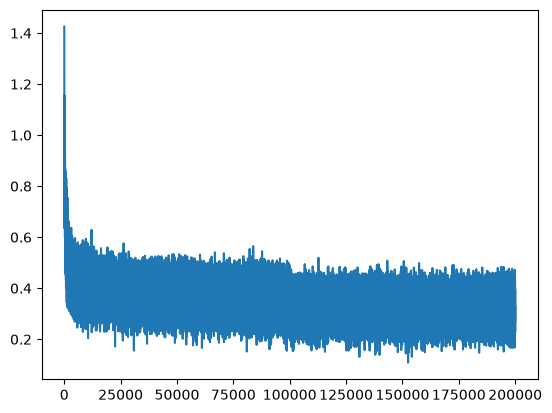

In [442]:
plt.plot(stepi, lossi)

In [443]:
# Above is only the loss of the minibatch
# let\'s get a full sense of the loss across the entire set
emb = C[Xtr] # create our embedding by looking up from table C
h = torch.tanh(emb.view(-1, n_inputs) @ W1 + b1) # hidden layer output, tanh taken
logits = h @ W2 + b2 # output layer
loss = F.cross_entropy(logits, Ytr)
print(f'Loss across full train set: {loss.item()}')

print('')
emb = C[Xdev] # create our embedding by looking up from table C
h = torch.tanh(emb.view(-1, n_inputs) @ W1 + b1) # hidden layer output, tanh taken
logits = h @ W2 + b2 # output layer
loss = F.cross_entropy(logits, Ydev)
print(f'Loss across dev set: {loss.item()}')

print('')
emb = C[Xte] # create our embedding by looking up from table C
h = torch.tanh(emb.view(-1, n_inputs) @ W1 + b1) # hidden layer output, tanh taken
logits = h @ W2 + b2 # output layer
loss = F.cross_entropy(logits, Yte)
print(f'Loss across test set: {loss.item()}')

Loss across full train set: 2.1381053924560547

Loss across dev set: 2.1825461387634277

Loss across test set: 2.1871721744537354


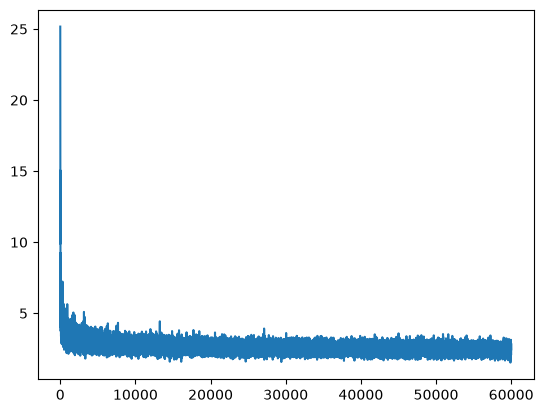

In [406]:
plt.plot(stepi, lossi)

We see that the loss minimizes at between lre of -1 and -0.5. So our 0.1 step size before was actually pretty good


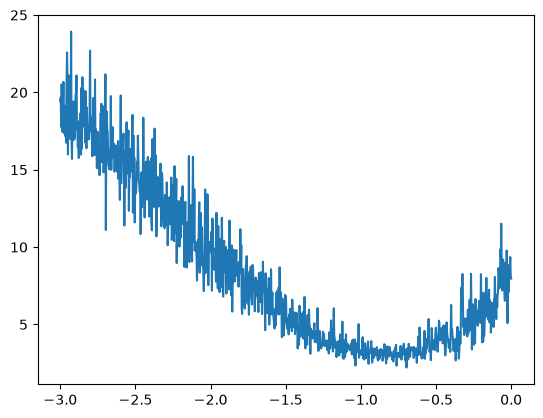

In [304]:
# plt.plot(lri,lossi)
plt.plot(lrei,lossi)
print('We see that the loss minimizes at between lre of -1 and -0.5. So our 0.1 step size before was actually pretty good')
# with this we continue with our learning rate and run the simulation for many steps.
# it is also common to perform a learning rate decay, where we decrease the learning rate in the end stages of simulation to get as close to the minima as possible without overshooting

In [ ]:
# Applying everything above, we see that our loss is lower than the bigram model in 3.1 - makemore follow along.ipynb.
# While this may seem good, it's more complicated because we are training a larger NN and there is a distinct possibility for overfitting. 
# Thus far we've been training on the full dataset. Typically in production, the dataset is split into train/validation/test sets (80/10/10)
# The training set is for, well, training.
# Validation is for training hyperparameters.
# Test set is used to evaluate the model performance at the end. We want to limit using the test set for testing because we want to avoid leaking test information into the model.

In [ ]:
# applying the train/validation/test split, we see that our model has very similar errors between three sets. This indicates we are likely not overfitting
# this model we are running is not powerful enough to purely memorize our data so overfitting is unlikely

# this also means our NN is very small. Hence, we expect to make performance improvements by scaling up the size of our NN
# making a bigger NN may also mean the NN takes longer to converge
# making the above NN bigger did indeed improve model performance

# Another possible bottleneck to our model is the dimensionality of our embeddings.
# we arbitrarily picked 2D, but that is not tested to be optimal for our model.

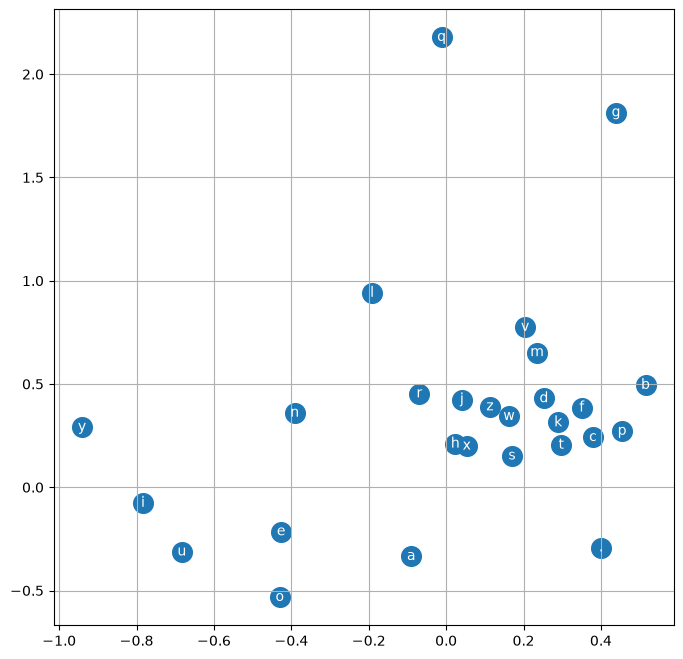

In [414]:
# before we modify the embedding, let's visualize the 2D embedding results

plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s = 200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

In [ ]:
# it's very interesting that vowels like aeiou (and y) are clustered close to each other.
# this tells us the model learned that vowels are more similar and interchangeable in names
# letters like q and . are quite far away from the remaining letters, and this makes sense as q is a very unique letter in names.
# not sure what is going on with g though

# now let's increase the embedding's dimensions
# increasing the embedding's dimensions did in fact lead to improved results!
# however, our model also seems to be overfitting now since we see the training loss and validation loss are starting to depart from one another.

In [462]:
# now let's try to sample from the model

g = torch.Generator().manual_seed(2147483647+10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with ...
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item() # remember, multinomial generates a sample based on the probabilities output by the model.
                                                                         # this is how we use the model to generate new outputs.
                                                                         # here we start blank, but we could potentially start with [0,0,1] to have a name that starts with 'a'
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

carmah.
amelle.
khi.
mri.
rehly.
hacey.
kenlynnel.
delynn.
jareei.
nellara.
chaiif.
kaleigh.
ham.
joce.
quinn.
shon.
walianni.
watelogiearynix.
kaeghirsan.
edye.
